## 05 · Forecast Model — Multi-Scale CNN + Dual Attention

Train a deep-learning RUL forecaster on C-MAPSS FD004 and evaluate on
a held-out engine set.

| | |
|---|---|
| Architecture | Parallel 1D CNN branches → Channel Attention → Temporal Attention → MLP |
| Ensemble | 10-seed, predictions **averaged** |
| Loss | SmoothL1 (Huber) |
| Optimiser | AdamW + Warmup + CosineAnnealingLR |
| Primary metric | Ensemble-averaged RMSE on holdout engines |

### What changed from the GRU baseline (train.py)
- **More features** — slopes and rolling std re-introduced where they
  provide independent information (see notebook 03 analysis). 56 features total.
- **Channel attention** (squeeze-excite) added before temporal attention —
  inspired by SOTA showing that weighting feature importance improves FD004.
- **Window size 50** — enough context for the largest CNN kernel (k=15),
  consistent with the GRU baseline window.
- **10-seed ensemble** (vs 5-seed baseline) for better variance reduction.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Paths ──
PROCESSED = Path('../data/processed')
RAW       = Path('../data/raw')
MODELS    = Path('../models')
FORECAST_DIR = MODELS / 'gru'          # saved under gru/ for backwards compat
FORECAST_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters (v5c — warmup + smooth cosine, 10-seed ensemble) ──
RUL_CAP           = 130
WINDOW_SIZE       = 50
STEP_TRAIN        = 1
STEP_HOLDOUT      = WINDOW_SIZE
CLIP_VAL          = 5.0
BATCH_SIZE        = 256
MAX_EPOCHS        = 200
PATIENCE          = 50
LR                = 5e-4
WEIGHT_DECAY      = 8e-4
NOISE_STD         = 0.02
HIDDEN            = 96
DROPOUT           = 0.35
GRAD_CLIP         = 1.0
FLEET_MEDIAN_LIFE = 239
SPLIT_SEED        = 33
N_VAL             = 25
N_HOLDOUT         = 25
ROLL_WINDOW       = 20
WARMUP_EPOCHS     = 10

# Multi-scale CNN + dual attention
KERNEL_SIZES      = [3, 5, 9, 15]
N_HEADS           = 2
SE_RATIO          = 4

# ── Ensemble (10 seeds) ──
SEEDS       = [42, 77, 123, 256, 512, 7, 31, 999, 1337, 2023]
N_SEEDS     = len(SEEDS)
PRINT_EVERY = 20

SENSORS = ['s2', 's3', 's4', 's7', 's8', 's11', 's13', 's14', 's15']

# Features dropped via permutation importance
DROP_FEATURES = {'slope_s3', 'n_s3', 'roll_std_s15', 'roll_std_s4'}

os.environ.setdefault('HSA_OVERRIDE_GFX_VERSION', '11.0.0')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_properties(0).name}')
print(f'Architecture: Multi-Scale CNN (kernels={KERNEL_SIZES}) + Channel SE + Temporal Attention ({N_HEADS} heads)')
print(f'Ensemble: {N_SEEDS} seeds, warmup={WARMUP_EPOCHS}ep + CosineAnnealing, patience={PATIENCE}')
print(f'Loss: SmoothL1 (Huber)  |  RUL cap: {RUL_CAP}  |  Window: {WINDOW_SIZE}')
print(f'Hidden: {HIDDEN}  |  Dropout: {DROPOUT}  |  Noise: {NOISE_STD}  |  LR: {LR}')

Device: cuda
GPU: AMD Radeon RX 7800 XT
Architecture: Multi-Scale CNN (kernels=[3, 5, 9, 15]) + Channel SE + Temporal Attention (2 heads)
Ensemble: 10 seeds, warmup=10ep + CosineAnnealing, patience=50
Loss: SmoothL1 (Huber)  |  RUL cap: 130  |  Window: 50
Hidden: 96  |  Dropout: 0.35  |  Noise: 0.02  |  LR: 0.0005


## 1 · Feature Engineering (v5 — 56-feature set)

56 features per timestep: condition-normalised sensors (n\_s\*), rolling mean/std,
OLS slope, EWMA, cycle×sensor interactions (cx), cycle-bin fleet deviation (CFD),
expanding std (exp\_std), operating settings (os1/2/3), and cycle\_norm.

Only four features are excluded via permutation importance: `slope_s3`, `n_s3`,
`roll_std_s15`, `roll_std_s4`.

In [2]:
df = pd.read_parquet(PROCESSED / 'FD004_train.parquet')
print(f'Loaded: {df.shape} — {df.unit.nunique()} engines')

# Merge os1/os2/os3 from raw data
raw_cols = ['unit', 'cycle'] + [f'os{i}' for i in range(1, 4)] + [f's{i}' for i in range(1, 22)]
raw = pd.read_csv(RAW / 'train_FD004.txt', sep=r'\s+', header=None, names=raw_cols)
df = df.merge(raw[['unit', 'cycle', 'os1', 'os2', 'os3']], on=['unit', 'cycle'], how='left')
print(f'Added os1/os2/os3 ({df[["os1","os2","os3"]].notna().all().all()} all non-null)')

Loaded: (61249, 42) — 249 engines
Added os1/os2/os3 (True all non-null)


In [3]:
# ── Feature Engineering (v5 — match GRU feature set) ─────────────────────────


def compute_rolling_features(df_in, window=ROLL_WINDOW):
    """Compute rolling mean, rolling std, and OLS slope per engine.
    Used for test data (training data already has these in parquet).
    """
    df = df_in.copy().sort_values(['unit', 'cycle'])
    for s in SENSORS:
        col = f'n_{s}'
        if col not in df.columns:
            continue
        grp = df.groupby('unit')[col]
        df[f'roll_mean_{s}'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        df[f'roll_std_{s}'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0))

        def rolling_slope(x):
            arr = x.values
            slopes = np.empty(len(arr))
            for i in range(len(arr)):
                start = max(0, i - window + 1)
                seg = arr[start:i + 1]
                if len(seg) < 3:
                    slopes[i] = 0.0
                else:
                    t = np.arange(len(seg), dtype=float)
                    slopes[i] = np.polyfit(t, seg, 1)[0]
            return pd.Series(slopes, index=x.index)

        df[f'slope_{s}'] = grp.transform(rolling_slope)
    return df


def compute_exp_std(df_in):
    """Expanding std per engine — captures accumulated sensor instability."""
    df = df_in.copy()
    for s in SENSORS:
        col = f'n_{s}'
        if col not in df.columns:
            continue
        df[f'exp_std_{s}'] = df.groupby('unit')[col].transform(
            lambda x: x.expanding(min_periods=2).std().fillna(0))
    return df


def add_derived_features(df_sub, train_df=None):
    """Add EWMA, cycle_norm, cycle×sensor interactions, and CFD features.
    Matches train.py feature engineering.
    """
    df_sub = df_sub.copy()

    # EWMA (span=20) for key sensors
    for s in ['s11', 's14', 's3', 's4']:
        col = f'n_{s}'
        if col in df_sub.columns:
            df_sub[f'ewma_{s}'] = df_sub.groupby('unit')[col].transform(
                lambda x: x.ewm(span=20, min_periods=1).mean())

    # Cycle normalised by fleet median (non-leaky)
    df_sub['cycle_norm'] = df_sub['cycle'] / FLEET_MEDIAN_LIFE

    # Cycle × rolling-mean interactions for key sensors
    for s in ['s11', 's14', 's3']:
        col = f'roll_mean_{s}'
        if col in df_sub.columns:
            df_sub[f'cx_{s}'] = df_sub['cycle_norm'] * df_sub[col]

    # Cycle-bin fleet deviation (CFD) — non-leaky
    ref = train_df if train_df is not None else df_sub
    cfd_sensors = ['s4', 's13', 's11', 's3']
    n_bins = 20
    max_cyc = ref['cycle'].max()
    edges = list(range(0, int(max_cyc) + n_bins + 1, n_bins))
    ref_copy = ref.copy()
    ref_copy['_cb'] = pd.cut(ref_copy['cycle'], bins=edges, labels=False)
    df_sub['_cb'] = pd.cut(df_sub['cycle'], bins=edges, labels=False)
    for s in cfd_sensors:
        col = f'n_{s}'
        if col in df_sub.columns:
            fleet_mean = ref_copy.groupby('_cb')[col].mean()
            df_sub[f'cfd_{s}'] = df_sub[col] - df_sub['_cb'].map(fleet_mean).fillna(0)
    df_sub = df_sub.drop(columns=['_cb'])
    return df_sub


def get_feature_columns(df):
    """GRU-style inclusive feature selection: keep everything, drop only harmful."""
    exclude = {'unit', 'cycle', 'rul', 'cycle_frac', 'condition', 'dataset'}
    return sorted(c for c in df.columns
                  if c not in exclude and c not in DROP_FEATURES
                  and float(df[c].std()) > 1e-12)

## 2 · Train / Val / Holdout Split + Windowing

In [4]:
# ── Split engines ─────────────────────────────────────────────────────────────
all_units = sorted(df['unit'].unique())
rng = np.random.RandomState(SPLIT_SEED)
perm = rng.permutation(all_units)
hu = perm[:N_HOLDOUT].tolist()
vu = perm[N_HOLDOUT:N_HOLDOUT + N_VAL].tolist()
tu = perm[N_HOLDOUT + N_VAL:].tolist()
print(f'Split seed={SPLIT_SEED}  Engines — train:{len(tu)} val:{len(vu)} holdout:{len(hu)}')

# Feature engineering per split — derived features + expanding std
dft = compute_exp_std(add_derived_features(df[df.unit.isin(tu)]))
dfv = compute_exp_std(add_derived_features(df[df.unit.isin(vu)], train_df=df[df.unit.isin(tu)]))
dfh = compute_exp_std(add_derived_features(df[df.unit.isin(hu)], train_df=df[df.unit.isin(tu)]))

feats = get_feature_columns(dft)
nc = len(feats)
print(f'Features ({nc}): {feats}')

Split seed=33  Engines — train:199 val:25 holdout:25
Features (56): ['cfd_s11', 'cfd_s13', 'cfd_s3', 'cfd_s4', 'cx_s11', 'cx_s14', 'cx_s3', 'cycle_norm', 'ewma_s11', 'ewma_s14', 'ewma_s3', 'ewma_s4', 'exp_std_s11', 'exp_std_s13', 'exp_std_s14', 'exp_std_s15', 'exp_std_s2', 'exp_std_s3', 'exp_std_s4', 'exp_std_s7', 'exp_std_s8', 'n_s11', 'n_s13', 'n_s14', 'n_s15', 'n_s2', 'n_s4', 'n_s7', 'n_s8', 'os1', 'os2', 'os3', 'roll_mean_s11', 'roll_mean_s13', 'roll_mean_s14', 'roll_mean_s15', 'roll_mean_s2', 'roll_mean_s3', 'roll_mean_s4', 'roll_mean_s7', 'roll_mean_s8', 'roll_std_s11', 'roll_std_s13', 'roll_std_s14', 'roll_std_s2', 'roll_std_s3', 'roll_std_s7', 'roll_std_s8', 'slope_s11', 'slope_s13', 'slope_s14', 'slope_s15', 'slope_s2', 'slope_s4', 'slope_s7', 'slope_s8']


## 3 · Windowing & Scaling

50-cycle windows with stride=1 for training, stride=50 (non-overlapping)
for holdout.  RobustScaler(5,95) fitted on train only, clipped to ±5.

In [5]:
def make_windows(df_engine, ws, step, feats):
    a = df_engine[feats].values.astype(np.float32)
    r = df_engine['rul'].values.astype(np.float32)
    T = len(a)
    if T < ws:
        a = np.vstack([np.zeros((ws - T, len(feats)), dtype=np.float32), a])
        r = np.concatenate([np.full(ws - T, r[0]), r])
        T = ws
    Xs, ys = [], []
    for i in range(0, T - ws + 1, step):
        Xs.append(a[i:i + ws])
        ys.append(r[i + ws - 1])
    return np.stack(Xs), np.array(ys, dtype=np.float32)


def build_dataset(df_sub, ws, step, feats):
    Xs, ys, us = [], [], []
    for u, g in df_sub.sort_values('cycle').groupby('unit'):
        X, y = make_windows(g, ws, step, feats)
        Xs.append(X); ys.append(y); us.extend([u] * len(y))
    return np.concatenate(Xs), np.concatenate(ys), np.array(us)


Xtr, ytr, _ = build_dataset(dft, WINDOW_SIZE, STEP_TRAIN, feats)
Xva, yva, _ = build_dataset(dfv, WINDOW_SIZE, STEP_TRAIN, feats)
Xho, yho, uho = build_dataset(dfh, WINDOW_SIZE, STEP_HOLDOUT, feats)
print(f'Windows — Tr:{Xtr.shape}  Va:{Xva.shape}  Ho:{Xho.shape}')

# ── Scaling ──
scaler = RobustScaler(quantile_range=(5, 95))
scaler.fit(Xtr.reshape(-1, nc))

def scale(X):
    N, T, C = X.shape
    return np.clip(
        scaler.transform(X.reshape(-1, C)).reshape(N, T, C).astype(np.float32),
        -CLIP_VAL, CLIP_VAL)

Xtr_s, Xva_s, Xho_s = scale(Xtr), scale(Xva), scale(Xho)
print(f'Scaled.  Train value range: [{Xtr_s.min():.2f}, {Xtr_s.max():.2f}]')

Windows — Tr:(39624, 50, 56)  Va:(4040, 50, 56)  Ho:(116, 50, 56)
Scaled.  Train value range: [-5.00, 5.00]


## 4 · Model — Multi-Scale CNN + Channel & Temporal Attention

**Architecture overview:**
```
Input (batch, 40, C)
       │
  ┌────┼────┬────┐
  │ k=3│ k=5│ k=9│ k=15    ← parallel 1D CNN branches (24ch each)
  └────┼────┴────┘
       │
  Concat → (batch, 40, 96)
       │
  Channel Attention (SE)        ← which features matter most?
       │
  Temporal Attention (2 heads)  ← which timesteps matter most?
       │
  Global Avg Pool → MLP → RUL
```

Sized for the richer feature set (cfd + exp_std + raw + context).
Hidden=96 (~85K params) balances capacity against the ~42K training windows.

In [6]:
class ForecastNet(nn.Module):
    """Multi-scale 1D CNN with channel + temporal attention for RUL prediction."""

    def __init__(self, n_in, hidden=128, dropout=0.3,
                 kernel_sizes=(3, 5, 9, 15), n_heads=4, se_ratio=4):
        super().__init__()
        n_branches = len(kernel_sizes)
        branch_dim = hidden // n_branches

        # Parallel CNN branches — each learns a different temporal scale
        self.branches = nn.ModuleList()
        for ks in kernel_sizes:
            self.branches.append(nn.Sequential(
                nn.Conv1d(n_in, branch_dim, kernel_size=ks, padding=ks // 2),
                nn.BatchNorm1d(branch_dim),
                nn.GELU(),
                nn.Conv1d(branch_dim, branch_dim, kernel_size=ks, padding=ks // 2),
                nn.BatchNorm1d(branch_dim),
                nn.GELU(),
            ))

        concat_dim = branch_dim * n_branches  # = hidden

        # Channel attention (squeeze-excite)
        self.se_pool = nn.AdaptiveAvgPool1d(1)
        self.se_fc = nn.Sequential(
            nn.Linear(concat_dim, concat_dim // se_ratio),
            nn.GELU(),
            nn.Linear(concat_dim // se_ratio, concat_dim),
            nn.Sigmoid(),
        )

        # Temporal self-attention
        self.attn = nn.MultiheadAttention(
            concat_dim, num_heads=n_heads, dropout=dropout, batch_first=True)
        self.attn_norm = nn.LayerNorm(concat_dim)

        # Prediction head
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(concat_dim, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        # x: (batch, seq_len, n_in)
        x_t = x.transpose(1, 2)  # → (batch, n_in, seq_len)

        branch_outs = [branch(x_t) for branch in self.branches]
        h = torch.cat(branch_outs, dim=1)  # (batch, hidden, seq_len)

        # Channel attention: squeeze-excite
        se_w = self.se_pool(h).squeeze(-1)           # (batch, hidden)
        se_w = self.se_fc(se_w).unsqueeze(-1)        # (batch, hidden, 1)
        h = h * se_w                                  # channel re-weighting

        h = h.transpose(1, 2)  # → (batch, seq_len, hidden)

        # Temporal self-attention with residual
        h_attn, _ = self.attn(h, h, h)
        h = self.attn_norm(h + h_attn)

        # Global average pool → prediction
        h = h.mean(dim=1)  # (batch, hidden)
        return self.fc(self.drop(h)).squeeze(-1)


# Verify
_m = ForecastNet(nc, HIDDEN, DROPOUT, KERNEL_SIZES, N_HEADS, SE_RATIO)
n_params = sum(p.numel() for p in _m.parameters())
print(f'ForecastNet: {n_params:,} parameters')
print(f'  branches: {KERNEL_SIZES}  |  hidden: {HIDDEN}  |  SE ratio: {SE_RATIO}')
print(f'  attention heads: {N_HEADS}  |  input: {nc} channels × {WINDOW_SIZE} steps')
del _m

ForecastNet: 108,889 parameters
  branches: [3, 5, 9, 15]  |  hidden: 96  |  SE ratio: 4
  attention heads: 2  |  input: 56 channels × 50 steps


## 5 · Training Loop (10-Seed Ensemble)

Each seed → 1 best-val checkpoint.  Warmup (10 ep, linear 0.1× → 1×) followed by
**CosineAnnealingLR** (T\_max=190, η\_min=1e-6) decays LR smoothly.
**Huber loss** (SmoothL1) reduces sensitivity to outlier predictions at the
high-RUL end.  Early stopping (patience=50) prevents wasteful training.

In [7]:
def train_one_seed(seed, Xtr_s, ytr, Xva_s, yva, nc):
    """Train with warmup → CosineAnnealing (no restarts) + Huber loss."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = ForecastNet(
        nc, HIDDEN, DROPOUT, KERNEL_SIZES, N_HEADS, SE_RATIO).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # Warmup → smooth cosine decay (no restarts)
    warmup_sched = torch.optim.lr_scheduler.LinearLR(
        opt, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
    cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=MAX_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        opt, schedulers=[warmup_sched, cosine_sched],
        milestones=[WARMUP_EPOCHS])

    crit = nn.SmoothL1Loss()  # Huber loss — robust to outliers

    tl = DataLoader(
        TensorDataset(torch.from_numpy(Xtr_s), torch.from_numpy(ytr)),
        BATCH_SIZE, shuffle=True, num_workers=2,
        pin_memory=True, persistent_workers=True)
    vl = DataLoader(
        TensorDataset(torch.from_numpy(Xva_s), torch.from_numpy(yva)),
        BATCH_SIZE, num_workers=2,
        pin_memory=True, persistent_workers=True)

    best_va, best_state = float('inf'), None
    wait = 0
    history = {'epoch': [], 'tr_rmse': [], 'va_rmse': [], 'lr': []}

    for ep in range(1, MAX_EPOCHS + 1):
        # ── Train ──
        model.train()
        sq, n = 0.0, 0
        for xb, yb in tl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            xb = xb + NOISE_STD * torch.randn_like(xb)
            p = model(xb)
            loss = crit(p, yb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            sq += ((p.detach() - yb) ** 2).sum().item()
            n += len(yb)
        tr_rmse = float(np.sqrt(sq / n))
        scheduler.step()

        # ── Validate ──
        model.eval()
        sq2, n2 = 0.0, 0
        with torch.no_grad():
            for xb, yb in vl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                sq2 += ((model(xb) - yb) ** 2).sum().item()
                n2 += len(yb)
        va_rmse = float(np.sqrt(sq2 / n2))

        current_lr = scheduler.get_last_lr()[0]
        history['epoch'].append(ep)
        history['tr_rmse'].append(tr_rmse)
        history['va_rmse'].append(va_rmse)
        history['lr'].append(current_lr)

        # ── Early stopping ──
        improved = va_rmse < best_va
        if improved:
            best_va = va_rmse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        # ── Print ──
        if improved or ep % PRINT_EVERY == 0 or ep == 1:
            marker = ' *' if improved else ''
            print(f'  ep {ep:>3d}  tr={tr_rmse:.2f}  va={va_rmse:.2f}  '
                  f'best={best_va:.2f}  lr={current_lr:.1e}  wait={wait}{marker}')

        if wait >= PATIENCE:
            print(f'  → Early stop at epoch {ep} (best val={best_va:.2f})')
            break

    del tl, vl
    gc.collect()
    return best_state, best_va, history


def ensemble_predict(X_s, states, nc):
    """Average predictions from all state dicts."""
    mdl = ForecastNet(
        nc, HIDDEN, DROPOUT, KERNEL_SIZES, N_HEADS, SE_RATIO).to(DEVICE)
    Xt = torch.from_numpy(X_s).to(DEVICE)
    preds = []
    for state in states:
        mdl.load_state_dict(state)
        mdl.eval()
        with torch.no_grad():
            preds.append(mdl(Xt).cpu().numpy())
    return np.mean(preds, axis=0)


# ── Train all seeds ──
print(f'Training {N_SEEDS}-seed ensemble: {SEEDS}')
print(f'ForecastNet h={HIDDEN} | {nc} features | SE_RATIO={SE_RATIO}')
print(f'SmoothL1Loss  AdamW(lr={LR}, wd={WEIGHT_DECAY})  noise={NOISE_STD}  clip={GRAD_CLIP}')
print(f'Warmup {WARMUP_EPOCHS}ep → CosineAnnealing(T_max={MAX_EPOCHS-WARMUP_EPOCHS})  patience={PATIENCE}')
print(f'Window={WINDOW_SIZE}  batch={BATCH_SIZE}')

all_states = []
all_val_rmses = []
all_histories = []
t0 = time.time()

for i, seed in enumerate(SEEDS):
    print(f'\n{"="*60}')
    print(f'SEED {i+1}/{N_SEEDS}: {seed}')
    print(f'{"="*60}')
    best_st, va_rmse, hist = train_one_seed(
        seed, Xtr_s, ytr, Xva_s, yva, nc)
    all_states.append(best_st)
    all_val_rmses.append(va_rmse)
    all_histories.append(hist)
    best_ep = hist['epoch'][hist['va_rmse'].index(va_rmse)]
    print(f'  → best val RMSE = {va_rmse:.2f}  (best at epoch {best_ep}, '
          f'trained {len(hist["epoch"])} epochs)')

n_models = len(all_states)
elapsed = time.time() - t0
print(f'\n{"="*60}')
print(f'All {N_SEEDS} seeds complete in {elapsed/60:.1f} min')
for i, (s, v) in enumerate(zip(SEEDS, all_val_rmses)):
    best_ep = all_histories[i]['epoch'][all_histories[i]['va_rmse'].index(v)]
    tr_at_best = all_histories[i]['tr_rmse'][all_histories[i]['epoch'].index(best_ep)]
    print(f'  seed={s}: val RMSE = {v:.2f}  '
          f'(best ep {best_ep}/{len(all_histories[i]["epoch"])}, tr@best={tr_at_best:.2f})')
print(f'Mean val RMSE: {np.mean(all_val_rmses):.2f}')
print(f'{"="*60}')

Training 10-seed ensemble: [42, 77, 123, 256, 512, 7, 31, 999, 1337, 2023]
ForecastNet h=96 | 56 features | SE_RATIO=4
SmoothL1Loss  AdamW(lr=0.0005, wd=0.0008)  noise=0.02  clip=1.0
Warmup 10ep → CosineAnnealing(T_max=190)  patience=50
Window=50  batch=256

SEED 1/10: 42
  ep   1  tr=96.82  va=86.93  best=86.93  lr=9.5e-05  wait=0 *
  ep   2  tr=93.58  va=82.49  best=82.49  lr=1.4e-04  wait=0 *
  ep   3  tr=87.58  va=74.76  best=74.76  lr=1.9e-04  wait=0 *
  ep   4  tr=76.90  va=61.69  best=61.69  lr=2.3e-04  wait=0 *
  ep   5  tr=59.23  va=41.58  best=41.58  lr=2.8e-04  wait=0 *
  ep   6  tr=34.95  va=22.07  best=22.07  lr=3.2e-04  wait=0 *
  ep   7  tr=18.43  va=19.34  best=19.34  lr=3.7e-04  wait=0 *
  ep   8  tr=16.73  va=18.65  best=18.65  lr=4.1e-04  wait=0 *
  ep  12  tr=14.54  va=17.50  best=17.50  lr=5.0e-04  wait=0 *
  ep  19  tr=12.83  va=16.96  best=16.96  lr=5.0e-04  wait=0 *
  ep  20  tr=12.93  va=18.93  best=16.96  lr=5.0e-04  wait=1
  ep  40  tr=11.66  va=18.85  best=1

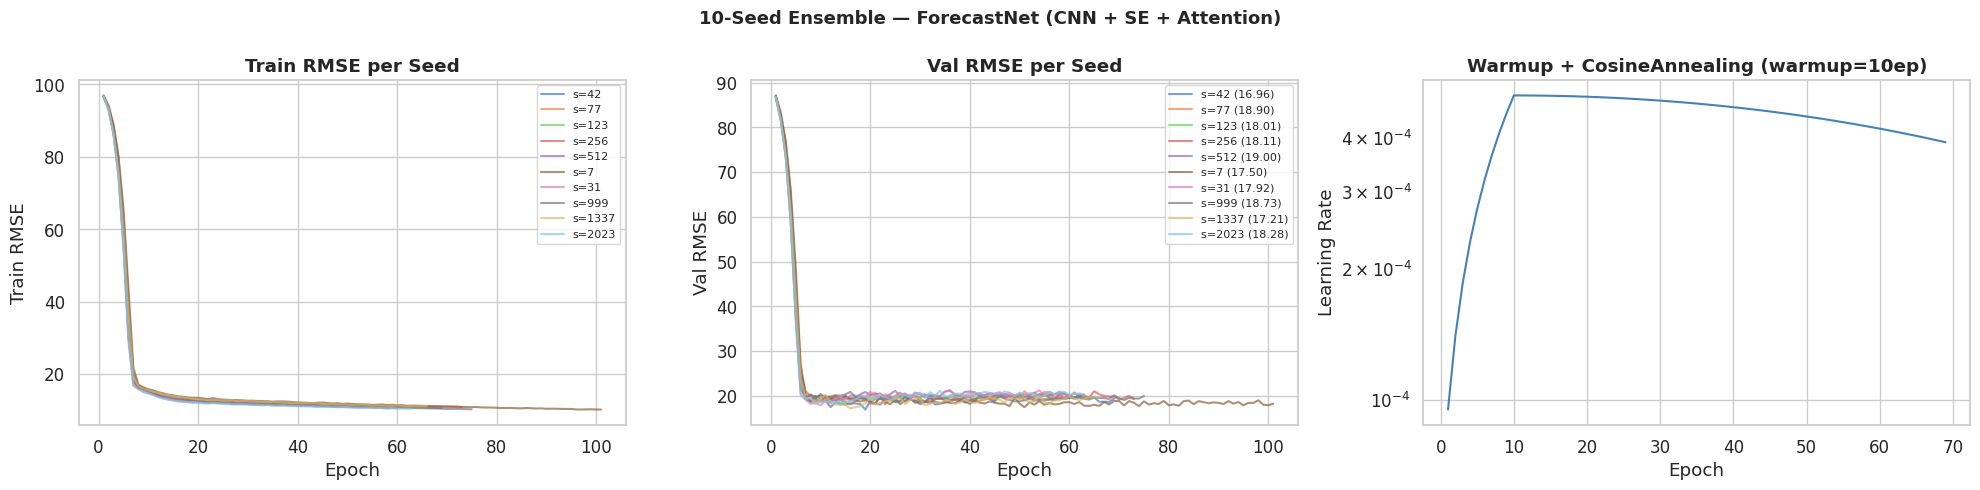

In [8]:
# ── Training curves ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (hist, seed) in enumerate(zip(all_histories, SEEDS)):
    axes[0].plot(hist['epoch'], hist['tr_rmse'], alpha=0.7, label=f's={seed}')
    axes[1].plot(hist['epoch'], hist['va_rmse'], alpha=0.7,
                 label=f's={seed} ({all_val_rmses[i]:.2f})')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train RMSE')
axes[0].set_title('Train RMSE per Seed', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val RMSE')
axes[1].set_title('Val RMSE per Seed', fontweight='bold')
axes[1].legend(fontsize=8)

# Learning rate schedule (from first seed)
axes[2].plot(all_histories[0]['epoch'], all_histories[0]['lr'],
             color='steelblue', lw=1.5)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title(f'Warmup + CosineAnnealing (warmup={WARMUP_EPOCHS}ep)', fontweight='bold')
axes[2].set_yscale('log')

plt.suptitle(f'{N_SEEDS}-Seed Ensemble — ForecastNet (CNN + SE + Attention)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── Training summary ──
print(f'Ensemble: {len(all_states)} models  (seeds={SEEDS})')
print('-' * 60)
for i, (s, v) in enumerate(zip(SEEDS, all_val_rmses)):
    best_idx = all_histories[i]['va_rmse'].index(v)
    best_ep  = all_histories[i]['epoch'][best_idx]
    tr_at_best = all_histories[i]['tr_rmse'][best_idx]
    total_ep = len(all_histories[i]['epoch'])
    print(f'  seed={s:>4d}: val={v:.2f}  best_ep={best_ep}/{total_ep}  tr@best={tr_at_best:.2f}')
print('-' * 60)
print(f'Mean val RMSE: {np.mean(all_val_rmses):.2f}')

Ensemble: 10 models  (seeds=[42, 77, 123, 256, 512, 7, 31, 999, 1337, 2023])
------------------------------------------------------------
  seed=  42: val=16.96  best_ep=19/69  tr@best=12.83
  seed=  77: val=18.90  best_ep=8/58  tr@best=16.34
  seed= 123: val=18.01  best_ep=14/64  tr@best=14.03
  seed= 256: val=18.11  best_ep=23/73  tr@best=12.88
  seed= 512: val=19.00  best_ep=13/63  tr@best=13.88
  seed=   7: val=17.50  best_ep=51/101  tr@best=11.83
  seed=  31: val=17.92  best_ep=10/60  tr@best=14.73
  seed= 999: val=18.73  best_ep=25/75  tr@best=12.13
  seed=1337: val=17.21  best_ep=16/66  tr@best=13.68
  seed=2023: val=18.28  best_ep=13/63  tr@best=13.32
------------------------------------------------------------
Mean val RMSE: 18.06


## 6 · Holdout Evaluation (Ensemble Average)

Brief validation on the 25-engine holdout set.  Full test evaluation is in [06_evaluation.ipynb](06_evaluation.ipynb).

In [10]:
def nasa_score(y_true, y_pred):
    d = np.asarray(y_pred, float) - np.asarray(y_true, float)
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

# ── Ensemble holdout prediction (averaged, not cherry-picked) ──
ho_pred = ensemble_predict(Xho_s, all_states, nc)

rmse = float(np.sqrt(mean_squared_error(yho, ho_pred)))
mae_ = float(mean_absolute_error(yho, ho_pred))
nasa = nasa_score(yho, ho_pred)
bias = float(np.mean(ho_pred - yho))

print('='*60)
print(f'Holdout — {n_models}-model ensemble average (25 engines)')
print(f'  RMSE={rmse:.2f}  MAE={mae_:.2f}  NASA={nasa:.1f}  bias={bias:+.2f}')
print('='*60)

# Per-bucket breakdown
edges = [0, 25, 50, 75, 100, 130]
labels_b = ['0-25 (crit)', '26-50', '51-75', '76-100', '101-130']
print('\nPer-bucket (ensemble average):')
for lo, hi, lb in zip(edges[:-1], edges[1:], labels_b):
    mk = (yho >= lo) & (yho < hi)
    if mk.sum() > 0:
        br = float(np.sqrt(mean_squared_error(yho[mk], ho_pred[mk])))
        bb = float(np.mean(ho_pred[mk] - yho[mk]))
        print(f'  {lb:<16s} RMSE={br:.2f}  bias={bb:+.2f}  n={int(mk.sum())}')

Holdout — 10-model ensemble average (25 engines)
  RMSE=9.89  MAE=7.14  NASA=160.2  bias=-1.73

Per-bucket (ensemble average):
  0-25 (crit)      RMSE=3.82  bias=+1.17  n=9
  26-50            RMSE=8.99  bias=+4.73  n=16
  51-75            RMSE=8.04  bias=+3.00  n=9
  76-100           RMSE=14.56  bias=+6.95  n=16
  101-130          RMSE=10.89  bias=-6.15  n=10


## 7 · Save Model

In [11]:
save_path = FORECAST_DIR / 'forecast_model.pt'
torch.save({
    'model_states': all_states,
    'config': {
        'n_in': nc, 'hidden': HIDDEN, 'dropout': DROPOUT,
        'window_size': WINDOW_SIZE, 'rul_cap': RUL_CAP,
        'fleet_median_life': FLEET_MEDIAN_LIFE,
        'noise_std': NOISE_STD, 'lr': LR, 'weight_decay': WEIGHT_DECAY,
        'grad_clip': GRAD_CLIP, 'max_epochs': MAX_EPOCHS, 'patience': PATIENCE,
        'kernel_sizes': list(KERNEL_SIZES), 'n_heads': N_HEADS,
        'se_ratio': SE_RATIO,
        'architecture': 'ForecastNet',
        'warmup_epochs': WARMUP_EPOCHS,
        'roll_window': ROLL_WINDOW,
    },
    'features': feats,
    'seeds': SEEDS,
    'ensemble_size': n_models,
    'split_seed': SPLIT_SEED,
    'train_units': tu,
    'val_units': vu,
    'holdout_units': hu,
    'per_seed_val_rmse': all_val_rmses,
    'holdout_rmse': rmse,
    'holdout_mae': mae_,
    'holdout_nasa': nasa,
    'holdout_bias': bias,
}, save_path)
joblib.dump(scaler, FORECAST_DIR / 'forecast_scaler.pkl')

print(f'Saved → {save_path}')
print(f'Scaler → {FORECAST_DIR}/forecast_scaler.pkl')
print(f'Features ({nc}): {feats}')
print(f'Architecture: ForecastNet (kernels={list(KERNEL_SIZES)}, SE={SE_RATIO})')
print(f'Ensemble: {n_models} models (averaged)')
print(f'Holdout RMSE: {rmse:.2f}')
print(f'\nOfficial test evaluation → 06_evaluation.ipynb')

Saved → ../models/gru/forecast_model.pt
Scaler → ../models/gru/forecast_scaler.pkl
Features (56): ['cfd_s11', 'cfd_s13', 'cfd_s3', 'cfd_s4', 'cx_s11', 'cx_s14', 'cx_s3', 'cycle_norm', 'ewma_s11', 'ewma_s14', 'ewma_s3', 'ewma_s4', 'exp_std_s11', 'exp_std_s13', 'exp_std_s14', 'exp_std_s15', 'exp_std_s2', 'exp_std_s3', 'exp_std_s4', 'exp_std_s7', 'exp_std_s8', 'n_s11', 'n_s13', 'n_s14', 'n_s15', 'n_s2', 'n_s4', 'n_s7', 'n_s8', 'os1', 'os2', 'os3', 'roll_mean_s11', 'roll_mean_s13', 'roll_mean_s14', 'roll_mean_s15', 'roll_mean_s2', 'roll_mean_s3', 'roll_mean_s4', 'roll_mean_s7', 'roll_mean_s8', 'roll_std_s11', 'roll_std_s13', 'roll_std_s14', 'roll_std_s2', 'roll_std_s3', 'roll_std_s7', 'roll_std_s8', 'slope_s11', 'slope_s13', 'slope_s14', 'slope_s15', 'slope_s2', 'slope_s4', 'slope_s7', 'slope_s8']
Architecture: ForecastNet (kernels=[3, 5, 9, 15], SE=4)
Ensemble: 10 models (averaged)
Holdout RMSE: 9.89

Official test evaluation → 06_evaluation.ipynb


## 8 · Summary

**ForecastNet v5c** — Multi-Scale CNN + Squeeze-Excite + Temporal Attention

| Config | Value |
|--------|-------|
| Features | 56 (n\_s\*, roll\_mean/std, slope, EWMA, cx, CFD, exp\_std, os1-3, cycle\_norm) |
| Window | 50 steps |
| Hidden | 96 |
| Architecture | Multi-Scale CNN (kernels 3,5,9,15) + SE(ratio=4) + MHA(2 heads) |
| Loss | SmoothL1 (Huber) |
| Scheduler | Warmup 10ep → CosineAnnealing(T\_max=190) |
| LR / WD | 5e-4 / 8e-4 |
| Dropout / Noise | 0.35 / 0.02 |
| Ensemble | 10 seeds |

Holdout and per-seed metrics are printed in the cells above.  
**Official test evaluation** is handled entirely in [06_evaluation.ipynb](06_evaluation.ipynb) to keep a single source of truth for reported scores.